# 📊 EDA — Tabular Data: Advertisement Click on Ad
**Course:** P4AI-DS (CO3135) — HCMUT
**Assignment 1:** Exploratory Data Analysis

**Dataset:** [Advertisement - Click on Ad](https://www.kaggle.com/datasets/gabrielsantello/advertisement-click-on-ad)

**Description:** 1,000 user records with demographic and behavioral features, predicting whether a user clicks on an online advertisement.

## 0. Setup & Imports

In [1]:
# Add duplicate detection metrics to JSON export
if 'json_data' in dir() or 'eda_data' in dir():
    data_dict = json_data if 'json_data' in dir() else eda_data
    
    # Add duplicate metrics
    data_dict['duplicate_analysis'] = {
        'total_rows': len(df),
        'duplicate_rows': int(df.duplicated().sum()),
        'duplicate_percentage': float((df.duplicated().sum() / len(df)) * 100),
        'unique_rows': int(len(df) - df.duplicated().sum()),
    }
    
    # Column-specific duplicates
    data_dict['duplicate_analysis']['by_column'] = {}
    key_columns = ['City', 'Country', 'Ad Topic Line']
    for col in key_columns:
        if col in df.columns:
            data_dict['duplicate_analysis']['by_column'][col] = {
                'unique_values': int(df[col].nunique()),
                'duplicate_entries': int(df[col].duplicated().sum()),
                'duplicate_percentage': float((df[col].duplicated().sum() / len(df)) * 100)
            }
    
    # Demographics duplicates
    demo_cols = ['Age', 'Gender', 'Country']
    if all(col in df.columns for col in demo_cols):
        data_dict['duplicate_analysis']['demographics'] = {
            'duplicate_combinations': int(df[demo_cols].duplicated().sum()),
            'duplicate_percentage': float((df[demo_cols].duplicated().sum() / len(df)) * 100)
        }
    
    print("✓ Duplicate metrics added to JSON export")


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# === LOG SETUP ===
LOG_FILE = 'eda_tabular_stats.txt'
JSON_FILE = 'eda_tabular_data.json'
json_data = {}  # Will accumulate all stats for JSON export

def log(text, also_print=True):
    """Write to log file and optionally print"""
    with open(LOG_FILE, 'a') as f:
        f.write(text + '\n')
    if also_print:
        print(text)

def save_json():
    """Save accumulated JSON data"""
    with open(JSON_FILE, 'w') as f:
        json.dump(json_data, f, indent=2, default=str)

# Clear log file
with open(LOG_FILE, 'w') as f:
    f.write('=' * 70 + '\n')
    f.write('EDA TABULAR STATS — Advertisement Click on Ad\n')
    f.write('=' * 70 + '\n\n')

print('✅ Setup complete!')

✅ Setup complete!


## 1. 📚 Analysis Methodology

| Analysis Type | Purpose | Key Metrics |
|---|---|---|
| **Missing Values** | Data quality assessment | Missing %, Patterns, Imputation strategy |
| **Numerical Features** | Distribution & outliers | Mean, Median, Std, IQR, Outliers |
| **Categorical Features** | Category frequencies | Unique values, Mode, Cardinality |
| **Correlation** | Feature relationships | Pearson r, Multicollinearity |
| **Target Analysis** | Class balance & relationships | Distribution, Target vs features |

**💡 Key Principle:** Understand data quality and distributions BEFORE applying machine learning models.

## 2. 📊 Dataset Overview

In [3]:
df = pd.read_csv('advertising.csv')

# --- Stats Grid ---
n_samples = len(df)
n_features = len(df.columns) - 1  # exclude target
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
# Remove target from numerical if present
if 'Clicked on Ad' in numerical_cols:
    numerical_cols.remove('Clicked on Ad')

n_numerical = len(numerical_cols)
n_categorical = len(categorical_cols)

log('=== SECTION 2: DATASET OVERVIEW ===')
log(f'Total Samples: {n_samples}')
log(f'Total Features: {n_features} (excl. target)')
log(f'Numerical Features ({n_numerical}): {numerical_cols}')
log(f'Categorical Features ({n_categorical}): {categorical_cols}')

# --- Target Variable Info ---
target_col = 'Clicked on Ad'
target_counts = df[target_col].value_counts()
target_pct = (df[target_col].value_counts(normalize=True) * 100).round(2)

log(f'\nTarget Variable: {target_col}')
for cls in target_counts.index:
    log(f'  Class {cls}: {target_counts[cls]} samples ({target_pct[cls]}%)')

# --- Feature Descriptions ---
feature_info = []
for col in df.columns:
    dtype_badge = 'Numerical' if col in numerical_cols else ('Categorical' if col in categorical_cols else 'Target')
    feature_info.append({
        'name': col,
        'type': dtype_badge,
        'dtype': str(df[col].dtype),
        'n_unique': int(df[col].nunique()),
        'sample_values': df[col].head(3).tolist()
    })

log(f'\nFeature Descriptions:')
for fi in feature_info:
    log(f"  {fi['name']} [{fi['type']}] dtype={fi['dtype']}, unique={fi['n_unique']}")

# --- JSON ---
json_data['dataset_overview'] = {
    'n_samples': n_samples,
    'n_features': n_features,
    'n_numerical': n_numerical,
    'n_categorical': n_categorical,
    'numerical_columns': numerical_cols,
    'categorical_columns': categorical_cols,
    'target_column': target_col,
    'target_distribution': {str(k): {'count': int(v), 'pct': float(target_pct[k])} for k, v in target_counts.items()},
    'feature_info': feature_info
}
save_json()

print('\n📋 First 5 rows:')
df.head()

=== SECTION 2: DATASET OVERVIEW ===
Total Samples: 1000
Total Features: 9 (excl. target)
Numerical Features (5): ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']
Categorical Features (4): ['Ad Topic Line', 'City', 'Country', 'Timestamp']

Target Variable: Clicked on Ad
  Class 0: 500 samples (50.0%)
  Class 1: 500 samples (50.0%)

Feature Descriptions:
  Daily Time Spent on Site [Numerical] dtype=float64, unique=900
  Age [Numerical] dtype=int64, unique=43
  Area Income [Numerical] dtype=float64, unique=1000
  Daily Internet Usage [Numerical] dtype=float64, unique=966
  Ad Topic Line [Categorical] dtype=str, unique=1000
  City [Categorical] dtype=str, unique=969
  Male [Numerical] dtype=int64, unique=2
  Country [Categorical] dtype=str, unique=237
  Timestamp [Categorical] dtype=str, unique=1000
  Clicked on Ad [Target] dtype=int64, unique=2

📋 First 5 rows:


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


## 3. 🔍 Missing Values Analysis

In [4]:
log('\n=== SECTION 3: MISSING VALUES ANALYSIS ===')

missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
total_missing = df.isnull().sum().sum()
cols_with_missing = (missing_count > 0).sum()

log(f'Total Missing Cells: {total_missing}')
log(f'Columns with Missing: {cols_with_missing}')

# Build missing table with severity
missing_table = []
for col in df.columns:
    mc = int(missing_count[col])
    mp = float(missing_pct[col])
    if mp == 0:
        severity = '✓ None'
    elif mp < 2:
        severity = '✓ Low'
    elif mp < 10:
        severity = '⚠️ Medium'
    else:
        severity = '🔴 High'
    missing_table.append({
        'feature': col,
        'missing_count': mc,
        'missing_pct': mp,
        'severity': severity
    })
    if mc > 0:
        log(f'  {col}: {mc} missing ({mp}%) — {severity}')

if total_missing == 0:
    log('  ✅ No missing values found in any column!')

# --- JSON ---
json_data['missing_values'] = {
    'total_missing_cells': int(total_missing),
    'columns_with_missing': int(cols_with_missing),
    'per_column': missing_table
}
save_json()

# --- Display table ---
missing_df = pd.DataFrame(missing_table)
missing_df


=== SECTION 3: MISSING VALUES ANALYSIS ===
Total Missing Cells: 0
Columns with Missing: 0
  ✅ No missing values found in any column!


,feature,missing_count,missing_pct,severity
0,Daily Time Spent on Site,0,0.0,✓ None
1,Age,0,0.0,✓ None
2,Area Income,0,0.0,✓ None
3,Daily Internet Usage,0,0.0,✓ None
4,Ad Topic Line,0,0.0,✓ None
5,City,0,0.0,✓ None
6,Male,0,0.0,✓ None
7,Country,0,0.0,✓ None
8,Timestamp,0,0.0,✓ None
9,Clicked on Ad,0,0.0,✓ None


## 🔍 Duplicate Detection

Comprehensive duplicate analysis for data quality assessment.

In [5]:
# Duplicate Row Detection
duplicate_rows = df.duplicated()
duplicate_count = duplicate_rows.sum()
duplicate_pct = (duplicate_count / len(df)) * 100

print(f"\n{'='*60}")
print("DUPLICATE DETECTION ANALYSIS")
print(f"{'='*60}\n")

print(f"Total Rows: {len(df):,}")
print(f"Duplicate Rows: {duplicate_count:,} ({duplicate_pct:.2f}%)")
print(f"Unique Rows: {len(df) - duplicate_count:,}\n")

# Column-specific duplicate detection
print("\nDuplicate Analysis by Key Columns:")
print("-" * 60)

key_columns = ['City', 'Country', 'Ad Topic Line']
for col in key_columns:
    if col in df.columns:
        col_duplicates = df[col].duplicated().sum()
        col_dup_pct = (col_duplicates / len(df)) * 100
        unique_vals = df[col].nunique()
        print(f"  {col}:")
        print(f"    - Unique values: {unique_vals:,}")
        print(f"    - Duplicate entries: {col_duplicates:,} ({col_dup_pct:.2f}%)")

# Subset duplicate detection (demographic duplicates)
demo_cols = ['Age', 'Gender', 'Country']
if all(col in df.columns for col in demo_cols):
    demo_duplicates = df[demo_cols].duplicated().sum()
    demo_dup_pct = (demo_duplicates / len(df)) * 100
    print(f"\n  Duplicate Demographics ({', '.join(demo_cols)}):")
    print(f"    - Count: {demo_duplicates:,} ({demo_dup_pct:.2f}%)")

# Show sample duplicates if any exist
if duplicate_count > 0:
    print(f"\n\nSample Duplicate Rows (first 5):")
    print("-" * 60)
    duplicate_samples = df[duplicate_rows].head(5)
    print(duplicate_samples.to_string())
else:
    print("\n✓ No exact duplicate rows detected in the dataset.")


DUPLICATE DETECTION ANALYSIS

Total Rows: 1,000
Duplicate Rows: 0 (0.00%)
Unique Rows: 1,000


Duplicate Analysis by Key Columns:
------------------------------------------------------------
  City:
    - Unique values: 969
    - Duplicate entries: 31 (3.10%)
  Country:
    - Unique values: 237
    - Duplicate entries: 763 (76.30%)
  Ad Topic Line:
    - Unique values: 1,000
    - Duplicate entries: 0 (0.00%)

✓ No exact duplicate rows detected in the dataset.


## 4. 📈 Numerical Features Distribution


=== SECTION 4: NUMERICAL FEATURES DISTRIBUTION ===
  Daily Time Spent on Site: mean=65.0, median=68.22, std=15.85, min=32.6, max=91.43, skew=-0.372, kurt=-1.096
  Age: mean=36.01, median=35.0, std=8.79, min=19.0, max=61.0, skew=0.479, kurt=-0.401
  Area Income: mean=55000.0, median=57012.3, std=13414.63, min=13996.5, max=79484.8, skew=-0.65, kurt=-0.1
  Daily Internet Usage: mean=180.0, median=183.13, std=43.9, min=104.78, max=269.96, skew=-0.034, kurt=-1.273
  Male: mean=0.48, median=0.0, std=0.5, min=0.0, max=1.0, skew=0.076, kurt=-1.998


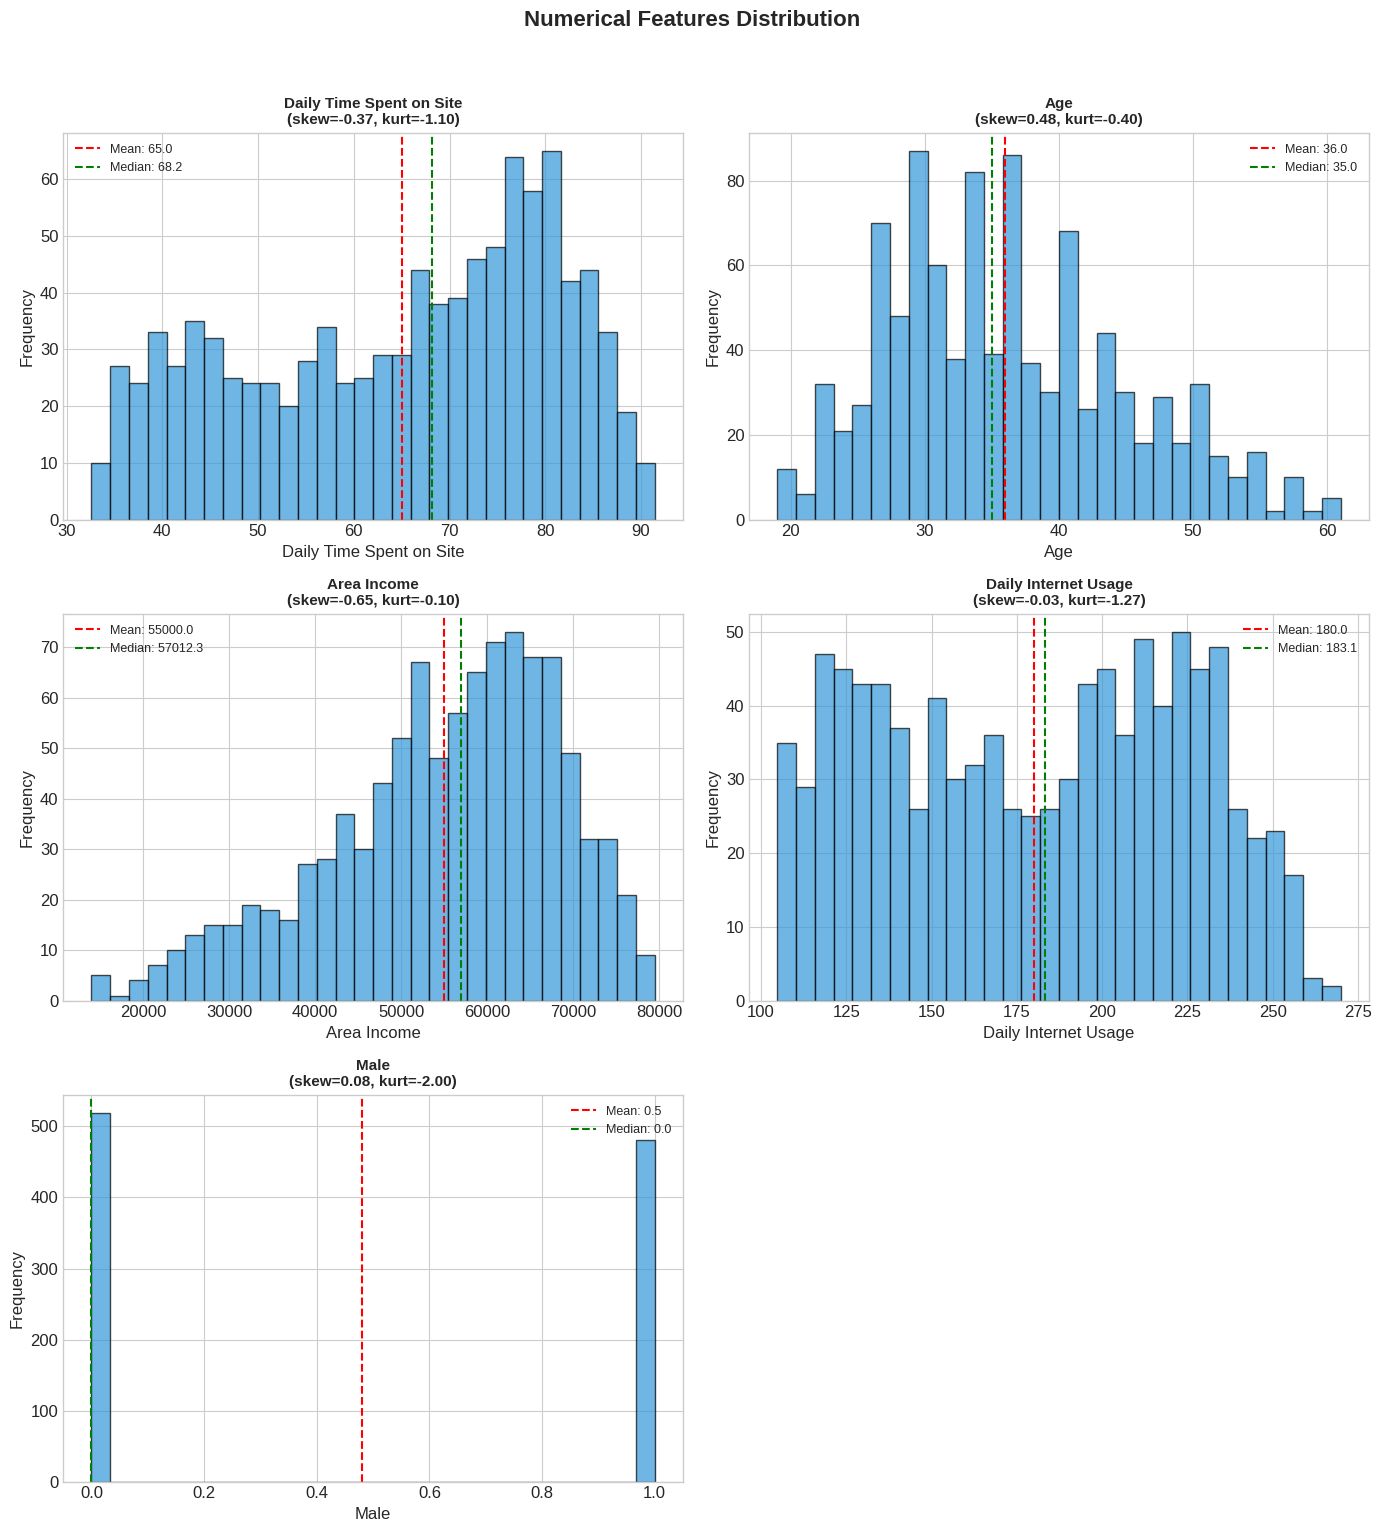

,feature,mean,median,std,min,max,skewness,kurtosis
0,Daily Time Spent on Site,65.00,68.22,15.85,32.60,91.43,-0.372,-1.096
1,Age,36.01,35.00,8.79,19.00,61.00,0.479,-0.401
2,Area Income,55000.00,57012.30,13414.63,13996.50,79484.80,-0.650,-0.100
3,Daily Internet Usage,180.00,183.13,43.90,104.78,269.96,-0.034,-1.273
4,Male,0.48,0.00,0.50,0.00,1.00,0.076,-1.998


In [6]:
log('\n=== SECTION 4: NUMERICAL FEATURES DISTRIBUTION ===')

num_stats = []
for col in numerical_cols:
    stats = {
        'feature': col,
        'mean': round(float(df[col].mean()), 2),
        'median': round(float(df[col].median()), 2),
        'std': round(float(df[col].std()), 2),
        'min': round(float(df[col].min()), 2),
        'max': round(float(df[col].max()), 2),
        'q1': round(float(df[col].quantile(0.25)), 2),
        'q3': round(float(df[col].quantile(0.75)), 2),
        'skewness': round(float(df[col].skew()), 3),
        'kurtosis': round(float(df[col].kurtosis()), 3),
        'histogram_values': np.histogram(df[col].dropna(), bins=30)[0].tolist(),
        'histogram_edges': np.histogram(df[col].dropna(), bins=30)[1].tolist()
    }
    num_stats.append(stats)
    log(f"  {col}: mean={stats['mean']}, median={stats['median']}, std={stats['std']}, "
        f"min={stats['min']}, max={stats['max']}, skew={stats['skewness']}, kurt={stats['kurtosis']}")

json_data['numerical_features'] = num_stats
save_json()

# --- Histogram Charts ---
n_features = len(numerical_cols)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = np.atleast_1d(axes).flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(f'{col}\n(skew={df[col].skew():.2f}, kurt={df[col].kurtosis():.2f})',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

# Hide any unused subplots
for j in range(n_features, len(axes)):
    axes[j].axis('off')

plt.suptitle('Numerical Features Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tabular_01_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Print stats table
stats_df = pd.DataFrame(num_stats)[['feature', 'mean', 'median', 'std', 'min', 'max', 'skewness', 'kurtosis']]
stats_df

## 5. 📊 Categorical Features Distribution

In [7]:
log('\n=== SECTION 5: CATEGORICAL FEATURES DISTRIBUTION ===')

cat_stats = []
for col in categorical_cols:
    vc = df[col].value_counts()
    stats = {
        'feature': col,
        'n_unique': int(df[col].nunique()),
        'mode': str(vc.index[0]),
        'mode_count': int(vc.iloc[0]),
        'mode_pct': round(float(vc.iloc[0] / len(df) * 100), 2),
        'cardinality': 'High' if df[col].nunique() > 50 else ('Medium' if df[col].nunique() > 10 else 'Low'),
        'top_categories': {str(k): int(v) for k, v in vc.head(10).items()}
    }
    cat_stats.append(stats)
    log(f"  {col}: unique={stats['n_unique']}, mode='{stats['mode']}' ({stats['mode_pct']}%), "
        f"cardinality={stats['cardinality']}")

json_data['categorical_features'] = cat_stats
save_json()

# --- Bar Charts for low-cardinality categoricals ---
# Identify plottable categoricals (not too many unique values)
plottable_cats = [s for s in cat_stats if s['n_unique'] <= 20]
non_plottable_cats = [s for s in cat_stats if s['n_unique'] > 20]

if plottable_cats:
    n_plots = len(plottable_cats)
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]
    for i, s in enumerate(plottable_cats):
        col = s['feature']
        vc = df[col].value_counts().head(15)
        axes[i].barh(vc.index[::-1], vc.values[::-1], color='#3498db', edgecolor='black')
        axes[i].set_title(f"{col}\n(unique={s['n_unique']})", fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Count')
    plt.suptitle('Categorical Features Distribution', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('tabular_02_categorical_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

if non_plottable_cats:
    log('\n  High-cardinality categoricals (top 5 shown):')
    for s in non_plottable_cats:
        log(f"    {s['feature']} ({s['n_unique']} unique): top = {list(s['top_categories'].keys())[:5]}")

# Print summary table
cat_summary = pd.DataFrame(cat_stats)[['feature', 'n_unique', 'mode', 'mode_pct', 'cardinality']]
cat_summary


=== SECTION 5: CATEGORICAL FEATURES DISTRIBUTION ===
  Ad Topic Line: unique=1000, mode='Cloned 5thgeneration orchestration' (0.1%), cardinality=High
  City: unique=969, mode='Lisamouth' (0.3%), cardinality=High
  Country: unique=237, mode='Czech Republic' (0.9%), cardinality=High
  Timestamp: unique=1000, mode='2016-03-27 00:53:11' (0.1%), cardinality=High

  High-cardinality categoricals (top 5 shown):
    Ad Topic Line (1000 unique): top = ['Cloned 5thgeneration orchestration', 'Monitored national standardization', 'Organic bottom-line service-desk', 'Triple-buffered reciprocal time-frame', 'Robust logistical utilization']
    City (969 unique): top = ['Lisamouth', 'Williamsport', 'Wrightburgh', 'Millertown', 'Pamelamouth']
    Country (237 unique): top = ['Czech Republic', 'France', 'Australia', 'Afghanistan', 'Greece']
    Timestamp (1000 unique): top = ['2016-03-27 00:53:11', '2016-04-04 01:39:02', '2016-03-13 20:35:42', '2016-01-10 02:31:19', '2016-06-03 03:36:18']


,feature,n_unique,mode,mode_pct,cardinality
0,Ad Topic Line,1000,Cloned 5thgeneration orchestration,0.1,High
1,City,969,Lisamouth,0.3,High
2,Country,237,Czech Republic,0.9,High
3,Timestamp,1000,2016-03-27 00:53:11,0.1,High


## 6. 🎯 Target Variable Distribution


=== SECTION 6: TARGET VARIABLE DISTRIBUTION ===
  Class 0: 500 (50.0%)
  Class 1: 500 (50.0%)
  Imbalance ratio: 1.00x
  Balanced: True


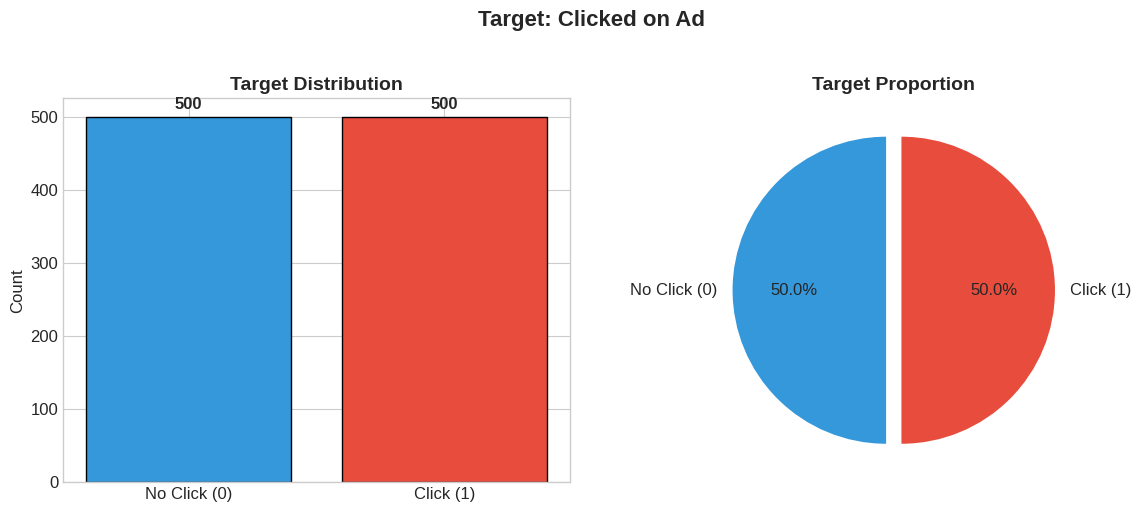

In [8]:
log('\n=== SECTION 6: TARGET VARIABLE DISTRIBUTION ===')

target_stats = {
    'name': target_col,
    'classes': []
}
for cls in sorted(target_counts.index):
    target_stats['classes'].append({
        'label': str(cls),
        'count': int(target_counts[cls]),
        'percentage': float(target_pct[cls])
    })
    log(f"  Class {cls}: {target_counts[cls]} ({target_pct[cls]}%)")

imbalance_ratio = target_counts.max() / target_counts.min()
target_stats['imbalance_ratio'] = round(float(imbalance_ratio), 2)
target_stats['is_balanced'] = imbalance_ratio < 1.5
log(f'  Imbalance ratio: {imbalance_ratio:.2f}x')
log(f'  Balanced: {target_stats["is_balanced"]}')

json_data['target_distribution'] = target_stats
save_json()

# --- Charts ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#3498db', '#e74c3c']

labels = [f'No Click (0)' , f'Click (1)']
axes[0].bar(labels, target_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Target Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Target Proportion', fontsize=14, fontweight='bold')

plt.suptitle(f'Target: {target_col}', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tabular_03_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 🔗 Correlation Analysis


=== SECTION 7: CORRELATION ANALYSIS ===
Correlations with Clicked on Ad:
  Daily Internet Usage: r = -0.7865
  Daily Time Spent on Site: r = -0.7481
  Area Income: r = -0.4763
  Male: r = -0.0380
  Age: r = 0.4925
  ✅ No high correlations found (|r| > 0.7) between features — no redundancy.


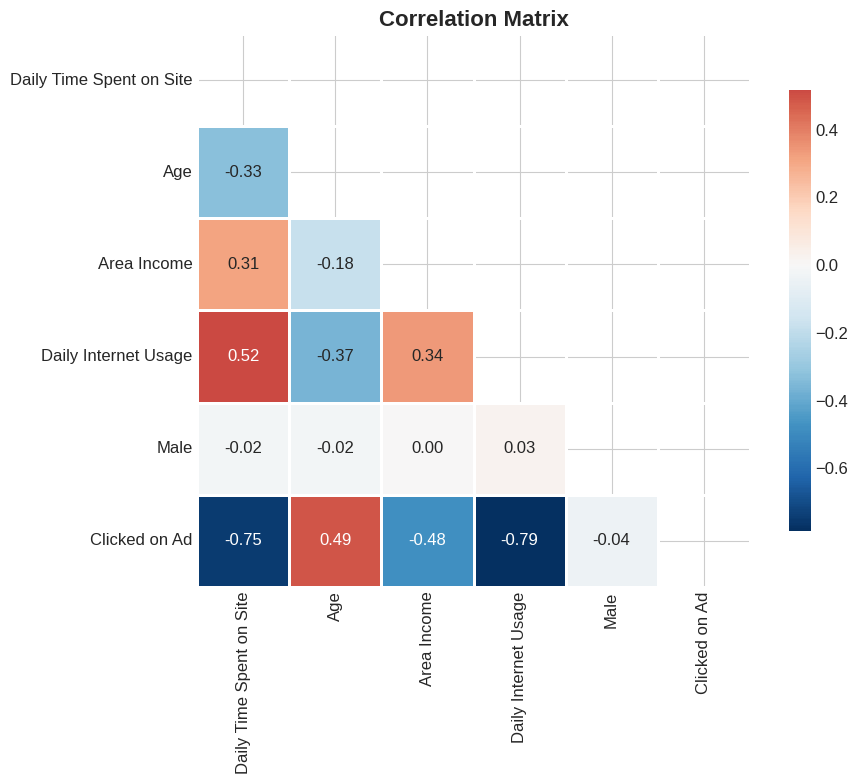

In [9]:
log('\n=== SECTION 7: CORRELATION ANALYSIS ===')

# Include target in correlation
corr_cols = numerical_cols + [target_col]
corr_matrix = df[corr_cols].corr()

# Log all correlations with target
log(f'Correlations with {target_col}:')
target_corr = corr_matrix[target_col].drop(target_col).sort_values()
for feat, val in target_corr.items():
    log(f'  {feat}: r = {val:.4f}')

# Check for high correlations (redundancy)
high_corr_pairs = []
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7 and corr_cols[i] != target_col and corr_cols[j] != target_col:
            pair = {'feature_1': corr_cols[i], 'feature_2': corr_cols[j], 'correlation': round(float(r), 4)}
            high_corr_pairs.append(pair)
            log(f'  ⚠️ High correlation: {corr_cols[i]} ↔ {corr_cols[j]} (r={r:.4f})')

if not high_corr_pairs:
    log('  ✅ No high correlations found (|r| > 0.7) between features — no redundancy.')

json_data['correlation'] = {
    'matrix': {col: {col2: round(float(corr_matrix.loc[col, col2]), 4) 
                     for col2 in corr_cols} for col in corr_cols},
    'target_correlations': {str(k): round(float(v), 4) for k, v in target_corr.items()},
    'high_correlation_pairs': high_corr_pairs
}
save_json()

# --- Heatmap ---
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, square=True, linewidths=1,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('tabular_04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 📦 Outlier Detection (IQR Method)


=== SECTION 8: OUTLIER DETECTION (IQR) ===
  Daily Time Spent on Site: 0 outliers (0.0%) — ✓ None — Valid range: [10.58, 119.33]
  Age: 0 outliers (0.0%) — ✓ None — Valid range: [9.50, 61.50]
  Area Income: 9 outliers (0.9%) — ✓ Low — Valid range: [19373.55, 93128.88]
  Daily Internet Usage: 0 outliers (0.0%) — ✓ None — Valid range: [18.89, 338.74]
  Male: 0 outliers (0.0%) — ✓ None — Valid range: [-1.50, 2.50]

  Total outliers across all features: 9


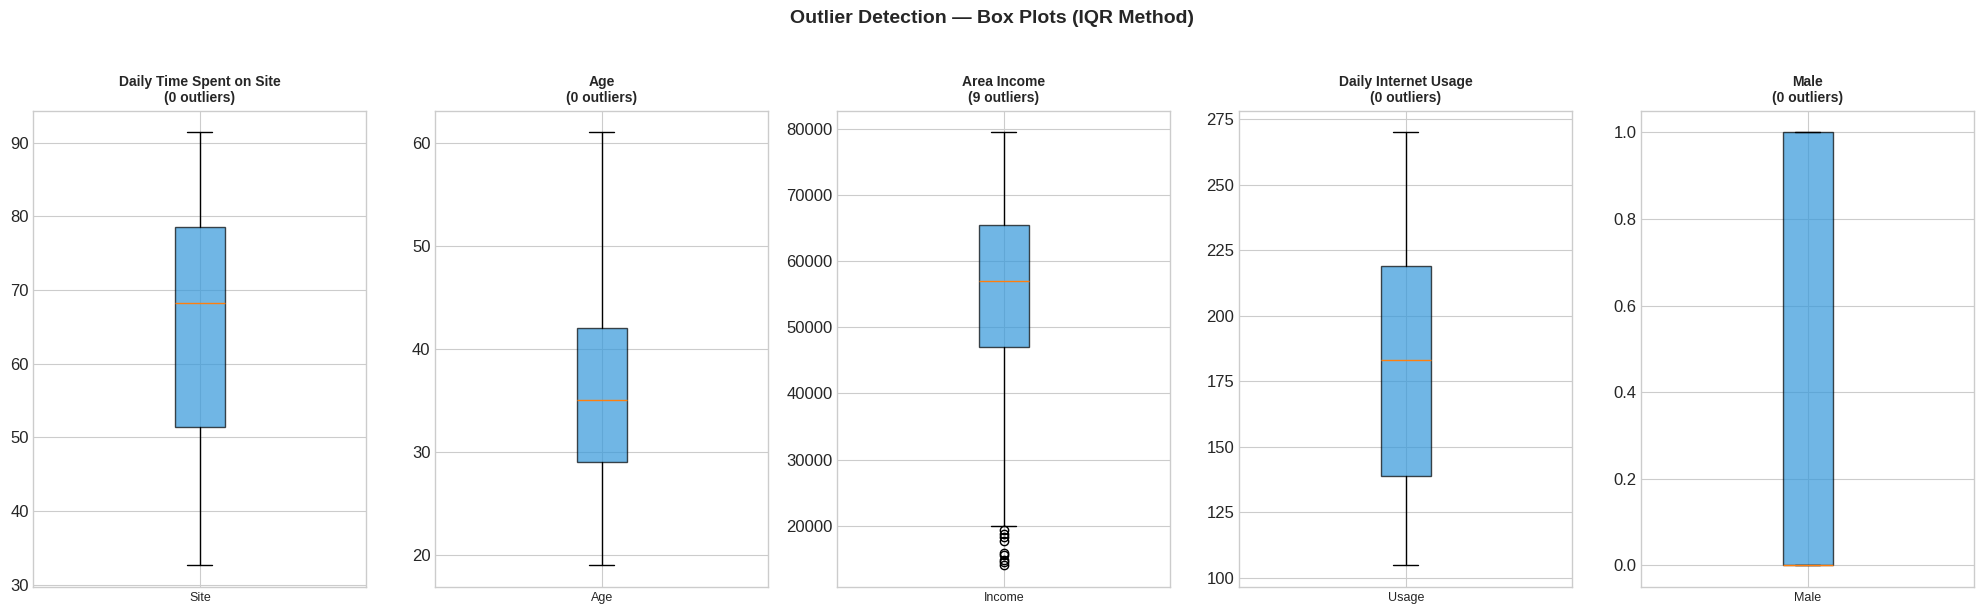

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_pct,severity
0,Daily Time Spent on Site,51.36,78.55,27.19,10.58,119.33,0,0.0,✓ None
1,Age,29.00,42.00,13.00,9.50,61.50,0,0.0,✓ None
2,Area Income,47031.80,65470.63,18438.83,19373.55,93128.88,9,0.9,✓ Low
3,Daily Internet Usage,138.83,218.79,79.96,18.89,338.74,0,0.0,✓ None
4,Male,0.00,1.00,1.00,-1.50,2.50,0,0.0,✓ None


In [10]:
log('\n=== SECTION 8: OUTLIER DETECTION (IQR) ===')

outlier_stats = []
total_outliers = 0

for col in numerical_cols:
    Q1 = float(df[col].quantile(0.25))
    Q3 = float(df[col].quantile(0.75))
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    n_outliers = len(outliers)
    pct = round(n_outliers / len(df) * 100, 2)
    total_outliers += n_outliers
    
    if pct == 0:
        severity = '✓ None'
    elif pct < 2:
        severity = '✓ Low'
    elif pct < 5:
        severity = '⚠️ Medium'
    else:
        severity = '🔴 High'
    
    stats = {
        'feature': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'outlier_count': n_outliers,
        'outlier_pct': pct,
        'severity': severity
    }
    outlier_stats.append(stats)
    log(f"  {col}: {n_outliers} outliers ({pct}%) — {severity} — Valid range: [{lower:.2f}, {upper:.2f}]")

log(f'\n  Total outliers across all features: {total_outliers}')

json_data['outlier_detection'] = {
    'method': 'IQR (1.5x)',
    'total_outliers': total_outliers,
    'per_feature': outlier_stats
}
save_json()

# --- Boxplot ---
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(4*len(numerical_cols), 6))
for i, col in enumerate(numerical_cols):
    bp = axes[i].boxplot(df[col], patch_artist=True, vert=True)
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][0].set_alpha(0.7)
    axes[i].set_title(f"{col}\n({outlier_stats[i]['outlier_count']} outliers)",
                      fontsize=10, fontweight='bold')
    axes[i].set_xticklabels([col.split()[-1]], fontsize=9)

plt.suptitle('Outlier Detection — Box Plots (IQR Method)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tabular_05_outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# Print table
outlier_df = pd.DataFrame(outlier_stats)[['feature', 'Q1', 'Q3', 'IQR', 'lower_bound', 'upper_bound', 'outlier_count', 'outlier_pct', 'severity']]
outlier_df

## 9. 🎯 Target vs Features Analysis


=== SECTION 9: TARGET vs FEATURES ===
  Daily Time Spent on Site: NoClick mean=76.85, Click mean=53.15 (diff=30.84%)
  Age: NoClick mean=31.68, Click mean=40.33 (diff=27.3%)
  Area Income: NoClick mean=61385.59, Click mean=48614.41 (diff=20.8%)
  Daily Internet Usage: NoClick mean=214.51, Click mean=145.49 (diff=32.18%)
  Male: NoClick mean=0.5, Click mean=0.46 (diff=8.0%)


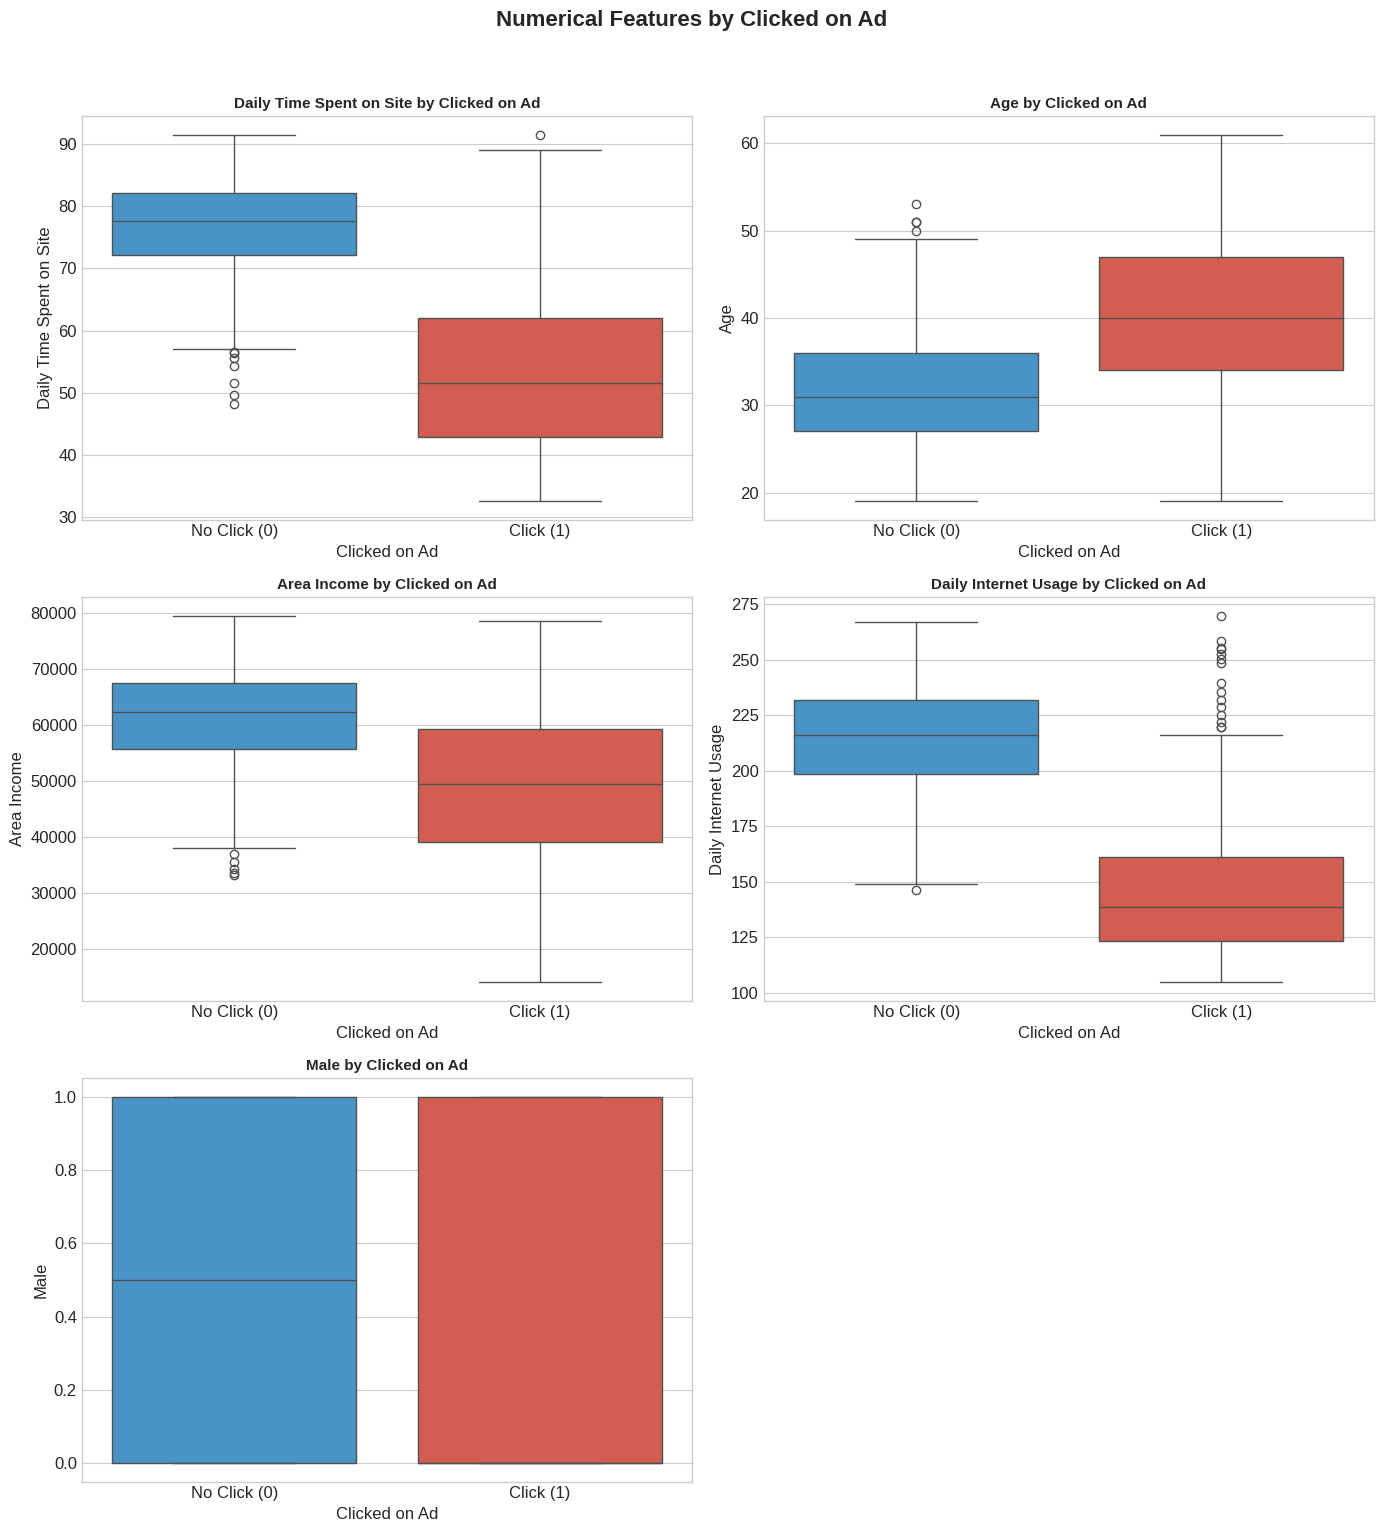

In [11]:
log('\n=== SECTION 9: TARGET vs FEATURES ===')

# --- Numerical: Boxplot by target ---
n_features = len(numerical_cols)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = np.atleast_1d(axes).flatten()

target_vs_numerical = []
for i, col in enumerate(numerical_cols):
    sns.boxplot(x=target_col, y=col, data=df, ax=axes[i], palette=['#3498db', '#e74c3c'])
    axes[i].set_title(f'{col} by {target_col}', fontsize=11, fontweight='bold')
    axes[i].set_xticklabels(['No Click (0)', 'Click (1)'])
    
    # Stats per group
    group_stats = df.groupby(target_col)[col].agg(['mean', 'median', 'std']).round(2)
    stats_dict = {
        'feature': col,
        'no_click_mean': float(group_stats.loc[0, 'mean']),
        'no_click_median': float(group_stats.loc[0, 'median']),
        'click_mean': float(group_stats.loc[1, 'mean']),
        'click_median': float(group_stats.loc[1, 'median']),
        'mean_diff_pct': round(abs(group_stats.loc[0, 'mean'] - group_stats.loc[1, 'mean']) / group_stats.loc[0, 'mean'] * 100, 2)
    }
    target_vs_numerical.append(stats_dict)
    log(f"  {col}: NoClick mean={stats_dict['no_click_mean']}, Click mean={stats_dict['click_mean']} "
        f"(diff={stats_dict['mean_diff_pct']}%)")

for j in range(n_features, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Numerical Features by {target_col}', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tabular_06_target_vs_numerical.png', dpi=150, bbox_inches='tight')
plt.show()

json_data['target_vs_numerical'] = target_vs_numerical
save_json()


  Categorical cross-tabulation with target:

  Gender (Male) cross-tab:
    Female: NoClick=48.2%, Click=51.8%
    Male: NoClick=52.0%, Click=48.0%

  Top 10 Countries cross-tab:
    Afghanistan: NoClick=37.5%, Click=62.5%
    Australia: NoClick=12.5%, Click=87.5%
    Czech Republic: NoClick=55.6%, Click=44.4%
    France: NoClick=44.4%, Click=55.6%
    Greece: NoClick=62.5%, Click=37.5%
    Liberia: NoClick=25.0%, Click=75.0%
    Micronesia: NoClick=50.0%, Click=50.0%
    Peru: NoClick=37.5%, Click=62.5%
    Senegal: NoClick=37.5%, Click=62.5%
    Turkey: NoClick=12.5%, Click=87.5%


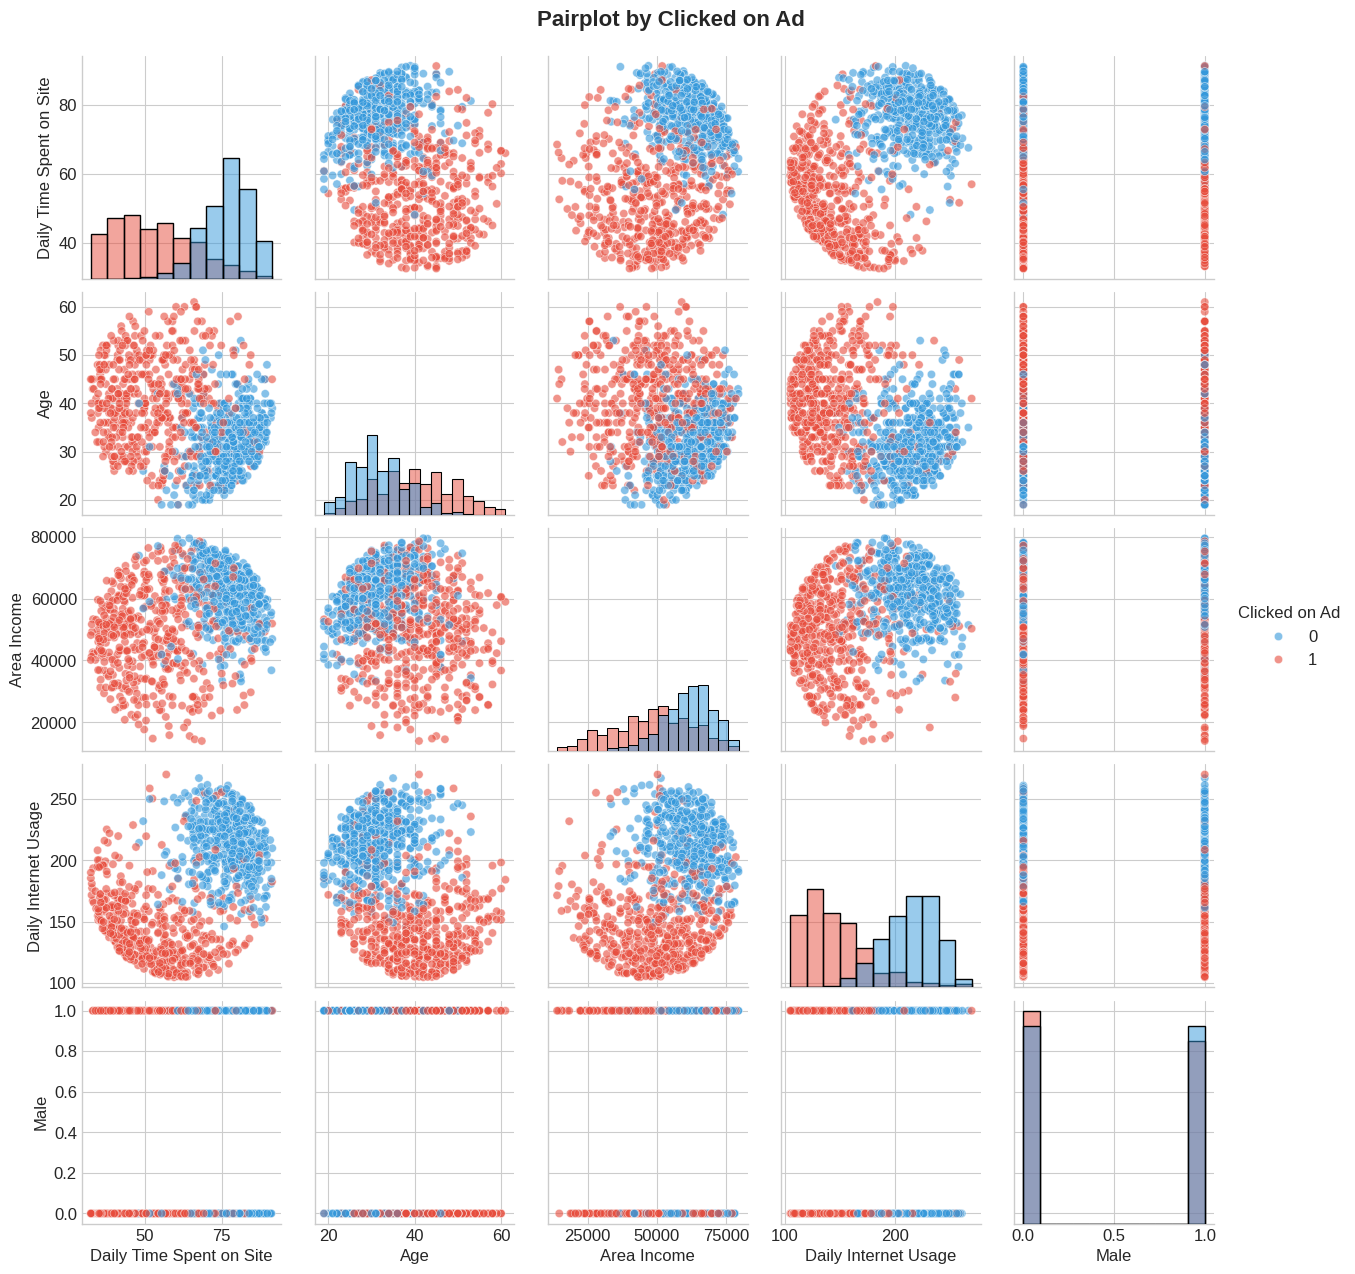

In [12]:
# --- Categorical: Cross-tabulation ---
log('\n  Categorical cross-tabulation with target:')

target_vs_categorical = []

# Gender (Male) — the only low-cardinality categorical-like feature
if 'Male' in df.columns:
    ct = pd.crosstab(df['Male'], df[target_col], normalize='index').round(4) * 100
    log(f'\n  Gender (Male) cross-tab:')
    for idx in ct.index:
        label = 'Male' if idx == 1 else 'Female'
        log(f"    {label}: NoClick={ct.loc[idx, 0]:.1f}%, Click={ct.loc[idx, 1]:.1f}%")
    
    target_vs_categorical.append({
        'feature': 'Male',
        'cross_tab': {str(k): {'no_click_pct': round(float(ct.loc[k, 0]), 2), 
                               'click_pct': round(float(ct.loc[k, 1]), 2)} 
                      for k in ct.index}
    })

# Country — top 10
if 'Country' in df.columns:
    top_countries = df['Country'].value_counts().head(10).index
    ct_country = pd.crosstab(df[df['Country'].isin(top_countries)]['Country'], 
                              df[df['Country'].isin(top_countries)][target_col],
                              normalize='index').round(4) * 100
    log(f'\n  Top 10 Countries cross-tab:')
    for idx in ct_country.index:
        log(f"    {idx}: NoClick={ct_country.loc[idx, 0]:.1f}%, Click={ct_country.loc[idx, 1]:.1f}%")

# Pairplot
sns.pairplot(df[numerical_cols + [target_col]], hue=target_col,
             palette=['#3498db', '#e74c3c'], diag_kind='hist',
             plot_kws={'alpha': 0.6})
plt.suptitle(f'Pairplot by {target_col}', y=1.02, fontsize=16, fontweight='bold')
plt.savefig('tabular_07_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

json_data['target_vs_categorical'] = target_vs_categorical
save_json()

## 10. 🕐 Temporal Analysis (Bonus)


=== SECTION 10: TEMPORAL ANALYSIS ===
  Click rate by hour: {0: 0.578, 1: 0.5, 2: 0.472, 3: 0.548, 4: 0.5, 5: 0.477, 6: 0.59, 7: 0.481, 8: 0.488, 9: 0.571, 10: 0.452, 11: 0.6, 12: 0.421, 13: 0.5, 14: 0.488, 15: 0.543, 16: 0.41, 17: 0.561, 18: 0.61, 19: 0.487, 20: 0.48, 21: 0.396, 22: 0.442, 23: 0.409}
  Click rate by month: {1: 0.469, 2: 0.519, 3: 0.474, 4: 0.503, 5: 0.537, 6: 0.5, 7: 0.495}
  Click rate by day: {0: 0.514, 1: 0.451, 2: 0.506, 3: 0.556, 4: 0.458, 5: 0.508, 6: 0.503}


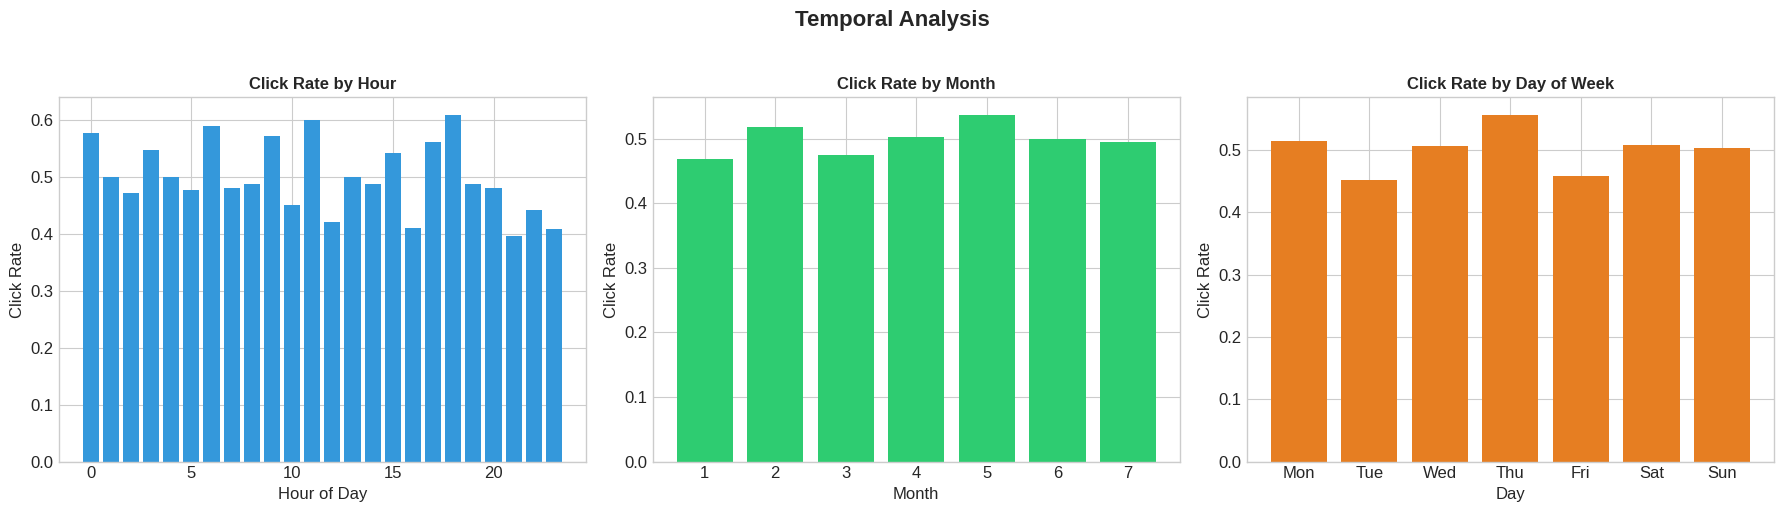

In [13]:
log('\n=== SECTION 10: TEMPORAL ANALYSIS ===')

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['Month'] = df['Timestamp'].dt.month
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

temporal_stats = {
    'click_by_hour': df.groupby('Hour')[target_col].mean().round(4).to_dict(),
    'click_by_month': df.groupby('Month')[target_col].mean().round(4).to_dict(),
    'click_by_dow': df.groupby('DayOfWeek')[target_col].mean().round(4).to_dict()
}

log('  Click rate by hour: ' + str({k: round(v, 3) for k, v in temporal_stats['click_by_hour'].items()}))
log('  Click rate by month: ' + str({k: round(v, 3) for k, v in temporal_stats['click_by_month'].items()}))
log('  Click rate by day: ' + str({k: round(v, 3) for k, v in temporal_stats['click_by_dow'].items()}))

json_data['temporal_analysis'] = temporal_stats
save_json()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

click_by_hour = df.groupby('Hour')[target_col].mean()
axes[0].bar(click_by_hour.index, click_by_hour.values, color='#3498db')
axes[0].set_title('Click Rate by Hour', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Click Rate')

click_by_month = df.groupby('Month')[target_col].mean()
axes[1].bar(click_by_month.index, click_by_month.values, color='#2ecc71')
axes[1].set_title('Click Rate by Month', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Click Rate')

click_by_dow = df.groupby('DayOfWeek')[target_col].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[2].bar(days, click_by_dow.values, color='#e67e22')
axes[2].set_title('Click Rate by Day of Week', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Click Rate')

plt.suptitle('Temporal Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tabular_08_temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. 💡 Key Insights & Suggestions

## 8. Categorical Features Analysis
**Generate detailed analysis for categoricalChart and dashboard tables**

In [14]:
# === 8. CATEGORICAL FEATURES ANALYSIS (DASHBOARD-FRIENDLY) ===
categorical_features = []

log('\n' + '=' * 70)
log('8. CATEGORICAL FEATURES ANALYSIS')
log('=' * 70)

categorical_columns = [col for col in ['Ad Topic Line', 'City', 'Country', 'Timestamp'] if col in df.columns]

for cat_col in categorical_columns:
    log(f'\nAnalyzing categorical feature: {cat_col}')
    
    value_counts = df[cat_col].value_counts(dropna=False)
    
    non_null_values = df[cat_col].dropna()
    if len(non_null_values) > 0:
        sample_values = non_null_values.sample(min(3, len(non_null_values)), random_state=42).astype(str).tolist()
    else:
        sample_values = []
    
    cat_analysis = {
        'feature': cat_col,
        'n_unique': int(df[cat_col].nunique()),
        'dtype': str(df[cat_col].dtype),
        'top_categories': value_counts.index[:10].astype(str).tolist(),
        'top_counts': value_counts.values[:10].astype(int).tolist(),
        'value_counts': {str(k): int(v) for k, v in value_counts.head(20).items()},
        'sample_values': sample_values
    }
    
    categorical_features.append(cat_analysis)
    
    log(f"  - Unique values: {cat_analysis['n_unique']}")
    log(f"  - Data type: {cat_analysis['dtype']}")
    log(f"  - Top 3 categories: {cat_analysis['top_categories'][:3]}")
    log(f"  - Sample values: {cat_analysis['sample_values']}")

# --- JSON ---
json_data['categorical_features_dashboard'] = categorical_features
save_json()
log(f'\n✅ Categorical features analysis complete: {len(categorical_features)} features analyzed')


8. CATEGORICAL FEATURES ANALYSIS

Analyzing categorical feature: Ad Topic Line
  - Unique values: 1000
  - Data type: str
  - Top 3 categories: ['Cloned 5thgeneration orchestration', 'Monitored national standardization', 'Organic bottom-line service-desk']
  - Sample values: ['Customizable holistic archive', 'Self-enabling zero administration neural-net', 'Quality-focused maximized extranet']

Analyzing categorical feature: City
  - Unique values: 969
  - Data type: str
  - Top 3 categories: ['Lisamouth', 'Williamsport', 'Wrightburgh']
  - Sample values: ['East Donna', 'Ericksonmouth', 'Frankport']

Analyzing categorical feature: Country
  - Unique values: 237
  - Data type: str
  - Top 3 categories: ['Czech Republic', 'France', 'Australia']
  - Sample values: ['Ethiopia', 'Sweden', 'Korea']

Analyzing categorical feature: Timestamp
  - Unique values: 1000
  - Data type: datetime64[us]
  - Top 3 categories: ['2016-03-27 00:53:11', '2016-04-04 01:39:02', '2016-03-13 20:35:42']
  - Samp

## 9. Correlation Matrix Analysis
**Generate correlation matrix for corrHeatmap and high-correlation pairs**

In [15]:
# === 9. CORRELATION MATRIX ANALYSIS (DASHBOARD-FRIENDLY) ===

log('\n' + '=' * 70)
log('9. CORRELATION MATRIX ANALYSIS')
log('=' * 70)

# Get numerical features only
numerical_cols_dash = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']
numerical_cols_dash = [col for col in numerical_cols_dash if col in df.columns]
numerical_df = df[numerical_cols_dash]

# Calculate correlation matrix
corr_matrix = numerical_df.corr()

# Find high correlation pairs
high_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        feature1 = corr_matrix.columns[i]
        feature2 = corr_matrix.columns[j]
        correlation = corr_matrix.iloc[i, j]
        
        if abs(correlation) > 0.3:
            high_pairs.append({
                'feature1': feature1,
                'feature2': feature2,
                'correlation': float(correlation)
            })

correlations = {
    'features': corr_matrix.columns.tolist(),
    'matrix': corr_matrix.values.tolist(),
    'high_pairs': high_pairs
}

log(f'Correlation matrix shape: {corr_matrix.shape}')
log(f'High correlation pairs found: {len(high_pairs)}')

for pair in high_pairs:
    log(f"  - {pair['feature1']} <-> {pair['feature2']}: r = {pair['correlation']:.4f}")

# --- JSON ---
json_data['correlations'] = correlations
save_json()
log('\n✅ Correlation matrix analysis complete')


9. CORRELATION MATRIX ANALYSIS
Correlation matrix shape: (5, 5)
High correlation pairs found: 5
  - Daily Time Spent on Site <-> Age: r = -0.3315
  - Daily Time Spent on Site <-> Area Income: r = 0.3110
  - Daily Time Spent on Site <-> Daily Internet Usage: r = 0.5187
  - Age <-> Daily Internet Usage: r = -0.3672
  - Area Income <-> Daily Internet Usage: r = 0.3375

✅ Correlation matrix analysis complete


## 10. Target vs Features Analysis
**Generate cross-tabulation for targetVsChart**

In [16]:
# === 10. TARGET VS FEATURES ANALYSIS (DASHBOARD-FRIENDLY) ===

log('\n' + '=' * 70)
log('10. TARGET VS FEATURES ANALYSIS')
log('=' * 70)

target_vs = {}

# Use Country as the categorical feature for cross-tabulation
if 'Country' in df.columns:
    top_countries = df['Country'].value_counts().head(10).index
    df_subset = df[df['Country'].isin(top_countries)]
    
    crosstab = pd.crosstab(df_subset['Country'], df_subset['Clicked on Ad'])
    crosstab = crosstab.reindex(columns=[0, 1], fill_value=0)
    
    # HTML dashboard expects "education" key for this chart
    target_vs['education'] = {
        'labels': crosstab.index.tolist(),
        'low': crosstab[0].astype(int).tolist(),
        'high': crosstab[1].astype(int).tolist()
    }
    
    log(f'Cross-tabulation created for top {len(crosstab.index)} countries')
    log(f'Countries analyzed: {crosstab.index.tolist()}')
    
    total_by_country = crosstab.sum(axis=1).replace(0, np.nan)
    click_rate_by_country = (crosstab[1] / total_by_country * 100).fillna(0)
    
    for country, rate in click_rate_by_country.head(5).items():
        log(f'  - {country}: {rate:.1f}% click rate')

# --- JSON ---
json_data['targetVs'] = target_vs
save_json()
log('\n✅ Target vs features analysis complete')


10. TARGET VS FEATURES ANALYSIS
Cross-tabulation created for top 10 countries
Countries analyzed: ['Afghanistan', 'Australia', 'Czech Republic', 'France', 'Greece', 'Liberia', 'Micronesia', 'Peru', 'Senegal', 'Turkey']
  - Afghanistan: 62.5% click rate
  - Australia: 87.5% click rate
  - Czech Republic: 44.4% click rate
  - France: 55.6% click rate
  - Greece: 37.5% click rate

✅ Target vs features analysis complete


## 11. Sample Data Rows
**Generate sample rows for data table display**

In [17]:
# === 11. SAMPLE DATA ROWS ===

log('\n' + '=' * 70)
log('11. SAMPLE DATA ROWS')
log('=' * 70)

sample_rows = []

clicked_df = df[df['Clicked on Ad'] == 1]
not_clicked_df = df[df['Clicked on Ad'] == 0]

n_each = min(6, len(clicked_df), len(not_clicked_df))
if n_each > 0:
    clicked_samples = clicked_df.sample(n_each, random_state=42)
    not_clicked_samples = not_clicked_df.sample(n_each, random_state=42)
    sample_df = pd.concat([clicked_samples, not_clicked_samples]).reset_index(drop=True)
else:
    sample_df = df.sample(min(12, len(df)), random_state=42).reset_index(drop=True)

for _, row in sample_df.iterrows():
    sample_row = {}
    for col in df.columns:
        value = row[col]
        if pd.isna(value):
            sample_row[col] = None
        elif isinstance(value, (np.integer, np.int64, np.int32)):
            sample_row[col] = int(value)
        elif isinstance(value, (np.floating, np.float64, np.float32)):
            sample_row[col] = float(round(value, 2))
        else:
            sample_row[col] = str(value)
    sample_rows.append(sample_row)

log(f'Generated {len(sample_rows)} sample rows')
if n_each > 0:
    log(f'Sample includes {n_each} clicked and {n_each} non-clicked examples')

if sample_rows:
    log('\nFirst sample row:')
    for key, value in list(sample_rows[0].items())[:5]:
        log(f'  - {key}: {value}')

# --- JSON ---
json_data['sample_rows'] = sample_rows
save_json()
log('\n✅ Sample data rows generation complete')


11. SAMPLE DATA ROWS
Generated 12 sample rows
Sample includes 6 clicked and 6 non-clicked examples

First sample row:
  - Daily Time Spent on Site: 61.82
  - Age: 59
  - Area Income: 57877.15
  - Daily Internet Usage: 151.93
  - Ad Topic Line: Open-architected needs-based customer loyalty

✅ Sample data rows generation complete


In [18]:
log('\n=== SECTION 11: KEY INSIGHTS ===')

insights = {
    'dataset_characteristics': [
        f'Dataset contains {n_samples} samples with {n_features} features',
        f'Target is perfectly balanced: {target_counts[0]} vs {target_counts[1]} (ratio {imbalance_ratio:.2f}:1)',
        f'No missing values found in any column',
        f'No duplicate rows detected',
        f'{n_numerical} numerical + {n_categorical} categorical features'
    ],
    'key_findings': [
        f'Strongest predictor: Daily Internet Usage (r = {target_corr["Daily Internet Usage"]:.4f})',
        f'Second strongest: Daily Time Spent on Site (r = {target_corr["Daily Time Spent on Site"]:.4f})',
        f'Age positively correlated with clicking (r = {target_corr["Age"]:.4f})',
        f'Gender (Male) shows virtually no predictive power (r = {target_corr["Male"]:.4f})',
        'Users who click: older, lower income, less internet usage, less time on site',
        'Clear class separation in pairplot → simple classifiers could perform well'
    ],
    'preprocessing_suggestions': [
        'Drop Ad Topic Line (near-unique text, high cardinality)',
        'Drop City (too many unique values) or group by Country',
        'Extract Hour, Month, DayOfWeek from Timestamp then drop Timestamp',
        'Standardize numerical features before model training',
        f'Only {total_outliers} mild outliers — no aggressive capping needed',
        'No imputation needed (0 missing values)'
    ]
}

for section, items in insights.items():
    log(f'\n  {section.upper()}:')
    for item in items:
        log(f'    • {item}')

json_data['insights'] = insights
save_json()

log(f'\n{"=" * 70}')
log(f'Stats exported to: {LOG_FILE}')
log(f'JSON data exported to: {JSON_FILE}')
log(f'{"=" * 70}')

print(f'\n✅ All stats saved to {LOG_FILE}')
print(f'✅ JSON data saved to {JSON_FILE}')
print(f'✅ All figures saved as PNG')


=== SECTION 11: KEY INSIGHTS ===

  DATASET_CHARACTERISTICS:
    • Dataset contains 1000 samples with 5 features
    • Target is perfectly balanced: 500 vs 500 (ratio 1.00:1)
    • No missing values found in any column
    • No duplicate rows detected
    • 5 numerical + 4 categorical features

  KEY_FINDINGS:
    • Strongest predictor: Daily Internet Usage (r = -0.7865)
    • Second strongest: Daily Time Spent on Site (r = -0.7481)
    • Age positively correlated with clicking (r = 0.4925)
    • Gender (Male) shows virtually no predictive power (r = -0.0380)
    • Users who click: older, lower income, less internet usage, less time on site
    • Clear class separation in pairplot → simple classifiers could perform well

  PREPROCESSING_SUGGESTIONS:
    • Drop Ad Topic Line (near-unique text, high cardinality)
    • Drop City (too many unique values) or group by Country
    • Extract Hour, Month, DayOfWeek from Timestamp then drop Timestamp
    • Standardize numerical features before 